In [ ]:
# ==============================================================================
#                 Change Detection — Inference & Visualisation
# ==============================================================================
#
#   Loads the trained U-Net and runs patch-based prediction
#   on 1024×1024 LEVIR-CD test images.
#
#   Inference strategy:
#     • No resizing — images stay at native 1024×1024.
#     • Each image is split into 16 non-overlapping 256×256 patches.
#     • Predictions for all 16 patches are stitched back into a
#       single 1024×1024 probability map before thresholding.
# ==============================================================================

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import random
import zipfile
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

In [ ]:
# CONFIG
class CFG:
    # ---- paths ---------------------------------------------------------------
    MODEL_PATH  = "/content/drive/MyDrive/Change Detection/best_model.pth"
    ZIP_PATH    = "/content/drive/MyDrive/Change Detection/dataset.zip"
    EXTRACT_DIR = "/content"
    DATA_ROOT   = "/content/dataset"

    # ---- patch strategy — must match training exactly -----------------------
    IMG_SIZE   = 1024
    PATCH_SIZE = 256
    GRID       = IMG_SIZE // PATCH_SIZE   # 4
    N_PATCHES  = GRID ** 2               # 16

    # ---- inference -----------------------------------------------------------
    THRESHOLD = 0.4
    DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] Device     : {CFG.DEVICE}")
print(f"[INFO] Patch size : {CFG.PATCH_SIZE}×{CFG.PATCH_SIZE}")
print(f"[INFO] Grid       : {CFG.GRID}×{CFG.GRID}  ({CFG.N_PATCHES} patches / image)")

[INFO] Device     : cuda
[INFO] Patch size : 256×256
[INFO] Grid       : 4×4  (16 patches / image)


In [ ]:
# DATASET SETUP
def setup_dataset():

    dataset_dir = Path("/content/LEVIR CD")
    local_zip   = Path("/content/dataset.zip")

    # 1. Dataset already extracted
    if dataset_dir.exists():
        CFG.DATA_ROOT = str(dataset_dir)
        print(f"✅ Dataset already exists → {CFG.DATA_ROOT}")
        return

    # 2. Verify Google Drive zip exists
    if not Path(CFG.ZIP_PATH).exists():
        raise FileNotFoundError(
            f"Dataset zip not found:\n{CFG.ZIP_PATH}"
        )

    # 3. Copy zip from Drive → local Colab storage
    print("Copying dataset.zip to local storage...")

    os.system(
        f'cp "{CFG.ZIP_PATH}" "/content/dataset.zip"'
    )

    if not local_zip.exists():
        raise RuntimeError("Failed to copy dataset.zip")

    # 4. Extract locally
    print("Extracting dataset locally...")

    try:
        with zipfile.ZipFile(local_zip, "r") as zf:
            zf.extractall("/content")

    except Exception as e:
        raise RuntimeError(
            f"Dataset extraction failed:\n{e}"
        )

    # 5. Verify extraction
    if not dataset_dir.exists():
        raise RuntimeError(
            "Extraction finished but '/content/LEVIR CD' not found."
        )

    CFG.DATA_ROOT = str(dataset_dir)

    print(f"✅ Dataset extracted → {CFG.DATA_ROOT}")

In [ ]:
setup_dataset()

Copying dataset.zip to local storage...
Extracting dataset locally...
✅ Dataset extracted → /content/LEVIR CD


In [ ]:
root = Path("/content/LEVIR CD")

print("\nTRAIN")
print("A:", len(list((root / "train" / "A").glob("*"))))
print("B:", len(list((root / "train" / "B").glob("*"))))
print("label:", len(list((root / "train" / "label").glob("*"))))

print("\nVAL")
print("A:", len(list((root / "val" / "A").glob("*"))))
print("B:", len(list((root / "val" / "B").glob("*"))))
print("label:", len(list((root / "val" / "label").glob("*"))))

print("\nTEST")
print("A:", len(list((root / "test" / "A").glob("*"))))
print("B:", len(list((root / "test" / "B").glob("*"))))
print("label:", len(list((root / "test" / "label").glob("*"))))


TRAIN
A: 445
B: 445
label: 445

VAL
A: 64
B: 64
label: 64

TEST
A: 128
B: 128
label: 128


In [ ]:
# U-NET ARCHITECTURE (identical to training notebook)
class ConvBlock(nn.Module):
    """Two consecutive Conv2d → BatchNorm → ReLU layers."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EncoderBlock(nn.Module):
    """ConvBlock → MaxPool. Returns (downsampled, skip)."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor):
        skip = self.conv(x)
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    """ConvTranspose2d upsample → concat skip → ConvBlock."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.pad(
                x,
                [0, skip.shape[3] - x.shape[3],
                 0, skip.shape[2] - x.shape[2]],
            )
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    Standard U-Net for binary change detection.
      Input  : B × 6 × H × W   (A and B patches concatenated)
      Output : B × 1 × H × W   (change probability map in [0, 1])
    """

    def __init__(
        self,
        in_ch: int = 6,
        out_ch: int = 1,
        features: tuple = (64, 128, 256, 512),
    ):
        super().__init__()

        self.enc1 = EncoderBlock(in_ch,        features[0])
        self.enc2 = EncoderBlock(features[0],  features[1])
        self.enc3 = EncoderBlock(features[1],  features[2])
        self.enc4 = EncoderBlock(features[2],  features[3])

        self.bottleneck = ConvBlock(features[3], features[3] * 2)

        self.dec4 = DecoderBlock(features[3] * 2, features[3])
        self.dec3 = DecoderBlock(features[3],     features[2])
        self.dec2 = DecoderBlock(features[2],     features[1])
        self.dec1 = DecoderBlock(features[1],     features[0])

        self.head = nn.Sequential(
            nn.Conv2d(features[0], out_ch, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x = self.bottleneck(x)
        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)
        return self.head(x)

In [ ]:
# LOAD MODEL
model = UNet(in_ch=6, out_ch=1).to(CFG.DEVICE)
model.load_state_dict(
    torch.load(CFG.MODEL_PATH, map_location=CFG.DEVICE)
)
model.eval()
print("✅ Model loaded successfully")

# ToTensor only — NO Resize (must match training)
img_tf = transforms.ToTensor()

✅ Model loaded successfully


In [ ]:
# PATCH-BASED INFERENCE WITH FULL-IMAGE RECONSTRUCTION
def predict_full_image(imgA_path, imgB_path):
    """
    Run the U-Net on all 16 non-overlapping 256×256 patches of a
    1024×1024 image pair and stitch the patch predictions back into
    a single 1024×1024 probability map.

    Parameters
    ----------
    imgA_path : str or Path — pre-change image
    imgB_path : str or Path — post-change image

    Returns
    -------
    imgA_np   : np.ndarray  H×W×3  float32  [0,1]  — image A as numpy
    imgB_np   : np.ndarray  H×W×3  float32  [0,1]  — image B as numpy
    full_pred : np.ndarray  H×W    float32  [0,1]  — probability map
    binary    : np.ndarray  H×W    uint8    {0,1}  — thresholded mask
    """
    # Load full-resolution images — no resize
    imgA = img_tf(Image.open(imgA_path).convert("RGB"))   # 3×1024×1024
    imgB = img_tf(Image.open(imgB_path).convert("RGB"))   # 3×1024×1024

    p         = CFG.PATCH_SIZE                            # 256
    S         = CFG.IMG_SIZE                              # 1024
    full_pred = np.zeros((S, S), dtype=np.float32)        # output canvas

    model.eval()
    with torch.no_grad():
        for row in range(CFG.GRID):         # 0 1 2 3
            for col in range(CFG.GRID):     # 0 1 2 3
                r0, r1 = row * p, (row + 1) * p
                c0, c1 = col * p, (col + 1) * p

                # Crop aligned 256×256 patches from A and B
                patchA = imgA[:, r0:r1, c0:c1]   # 3×256×256
                patchB = imgB[:, r0:r1, c0:c1]   # 3×256×256

                # Build 6-channel input, add batch dimension
                x = (
                    torch.cat([patchA, patchB], dim=0)
                    .unsqueeze(0)
                    .to(CFG.DEVICE)
                )                                 # 1×6×256×256

                # Predict and write into the correct tile of the canvas
                patch_pred = model(x).squeeze().cpu().numpy()   # 256×256
                full_pred[r0:r1, c0:c1] = patch_pred

    binary  = (full_pred > CFG.THRESHOLD).astype(np.uint8)
    imgA_np = imgA.permute(1, 2, 0).numpy()   # H×W×3
    imgB_np = imgB.permute(1, 2, 0).numpy()   # H×W×3

    return imgA_np, imgB_np, full_pred, binary

In [ ]:
# RANDOM SAMPLE HELPER
def get_random_samples(n: int = 5):
    """Return n randomly selected (A, B, label) path tuples from the test set."""
    root = Path(CFG.DATA_ROOT) / "test"
    A = sorted((root / "A").glob("*"))
    B = sorted((root / "B").glob("*"))
    L = sorted((root / "label").glob("*"))
    indices = random.sample(range(len(A)), n)
    return [(A[i], B[i], L[i]) for i in indices]

In [ ]:
# VISUALISE RANDOM SAMPLES
def visualize_random_samples(n: int = 2):
    """
    Randomly select n test images and display a 2-row panel for each:
      Row 1 : Image A (Before)  |  Image B (After)
      Row 2 : Ground Truth      |  U-Net Prediction

    All images are shown at their native 1024×1024 resolution.
    The prediction mask is reconstructed from 16 stitched patches.
    """
    samples = get_random_samples(n)

    # Print file paths
    for i, (a, b, l) in enumerate(samples):
        print(f"\nSample {i + 1}:")
        print(f"  A     : {a}")
        print(f"  B     : {b}")
        print(f"  Label : {l}")

    plt.figure(figsize=(14, 8 * n))

    for i, (a, b, l) in enumerate(samples):
        imgA_np, imgB_np, pred, binary = predict_full_image(a, b)

        # Load ground-truth label — ToTensor, then binarise (no resize)
        label = img_tf(Image.open(l).convert("L"))
        label = (label > 0.5).float().squeeze().numpy()   # 1024×1024

        row1 = 2 * i        # first subplot row for this sample
        row2 = 2 * i + 1    # second subplot row for this sample

        # ── Row 1 : A and B ───────────────────────────────────────────────
        plt.subplot(2 * n, 2, row1 * 2 + 1)
        plt.imshow(imgA_np)
        plt.title(f"Sample {i + 1} — Image A  (Before)")
        plt.axis("off")

        plt.subplot(2 * n, 2, row1 * 2 + 2)
        plt.imshow(imgB_np)
        plt.title(f"Sample {i + 1} — Image B  (After)")
        plt.axis("off")

        # ── Row 2 : Ground Truth and Prediction ───────────────────────────
        plt.subplot(2 * n, 2, row2 * 2 + 1)
        plt.imshow(label, cmap="gray")
        plt.title("Ground Truth  (1024×1024)")
        plt.axis("off")

        plt.subplot(2 * n, 2, row2 * 2 + 2)
        plt.imshow(binary, cmap="gray")
        plt.title("U-Net Prediction  (1024×1024 stitched)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Sample 1:
  A     : /content/LEVIR CD/test/A/test_102.png
  B     : /content/LEVIR CD/test/B/test_102.png
  Label : /content/LEVIR CD/test/label/test_102.png


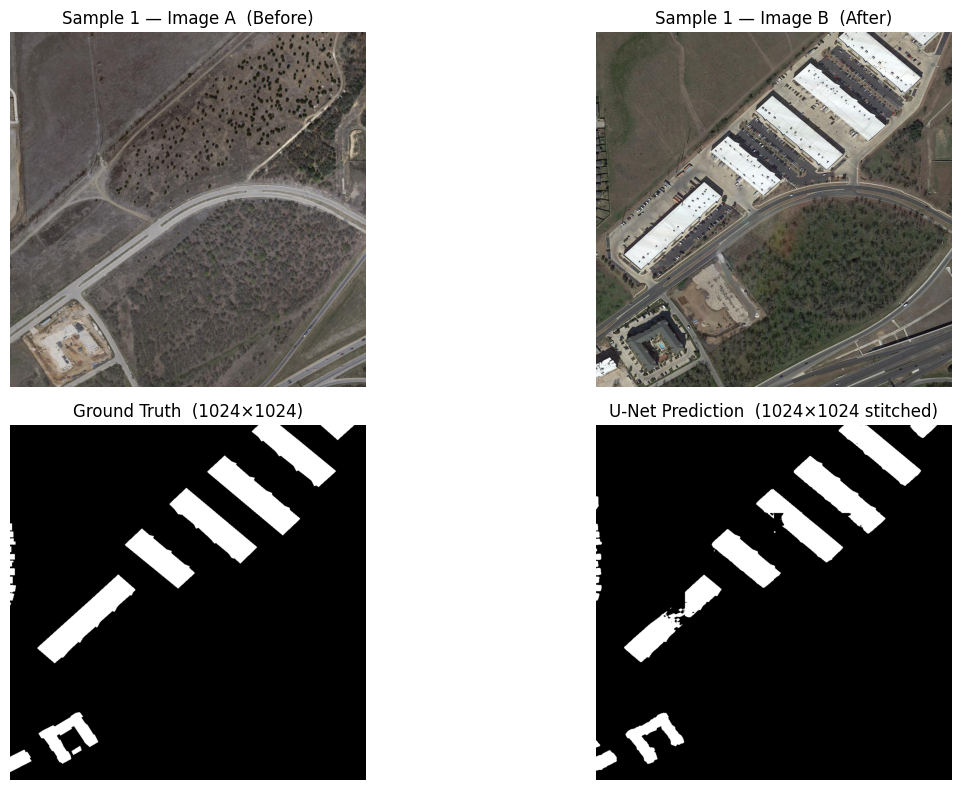

In [ ]:
visualize_random_samples(n = 1)

In [ ]:
# MANUAL VISUALISATION — single image pair
def visualize_manual(imgA_path, imgB_path, label_path=None):
    """
    Run inference on a specific image pair and display results.

    Parameters
    ----------
    imgA_path  : path to the pre-change image
    imgB_path  : path to the post-change image
    label_path : (optional) path to the ground-truth binary mask
                 If provided, ground truth is shown alongside the prediction.
    """
    imgA_np, imgB_np, pred, binary = predict_full_image(imgA_path, imgB_path)

    plt.figure(figsize=(14, 8))

    # Image A
    plt.subplot(2, 2, 1)
    plt.imshow(imgA_np)
    plt.title("Image A  (Before)")
    plt.axis("off")

    # Image B
    plt.subplot(2, 2, 2)
    plt.imshow(imgB_np)
    plt.title("Image B  (After)")
    plt.axis("off")

    # Ground truth (optional)
    if label_path is not None:
        label = img_tf(Image.open(label_path).convert("L"))
        label = (label > 0.5).float().squeeze().numpy()
        plt.subplot(2, 2, 3)
        plt.imshow(label, cmap="gray")
        plt.title("Ground Truth  (1024×1024)")
        plt.axis("off")

    # Prediction
    plt.subplot(2, 2, 4)
    plt.imshow(binary, cmap="gray")
    plt.title("U-Net Prediction  (1024×1024 stitched)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

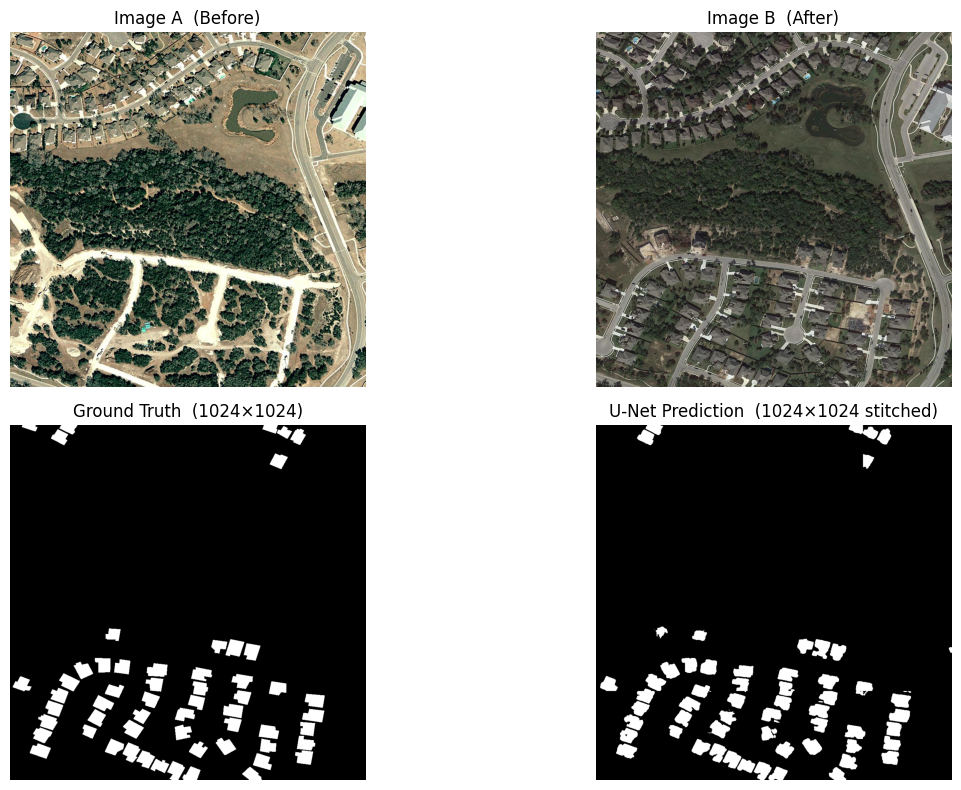

In [18]:
# EXAMPLE: run on a specific image
imgA_path  = "/content/LEVIR CD/test/A/test_8.png"
imgB_path  = "/content/LEVIR CD/test/B/test_8.png"
label_path = "/content/LEVIR CD/test/label/test_8.png"

visualize_manual(imgA_path, imgB_path, label_path)

In [20]:
SAVE_PATH = "/content/drive/MyDrive/Change Detection/Output Images/"

# Give your image paths
imgA_path = "/content/LEVIR CD/test/A/test_8.png"
imgB_path = "/content/LEVIR CD/test/B/test_8.png"

# Get prediction
imgA, imgB, pred, binary = predict_full_image(
    imgA_path,
    imgB_path
)

# Prediction is already reconstructed to full 1024×1024
unet = (binary * 255).astype("uint8")

# Save
cv2.imwrite(SAVE_PATH + "U-Net_Predicted.png", unet)

True